In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import seaborn as sns
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

In [5]:
DATA_DIR = Path("../data/processed/")
MESSAGES_PATH = Path("messages_classified_topics")

In [7]:
df = pd.read_parquet(DATA_DIR / MESSAGES_PATH)
print(f"Quantidade de mensagens: {len(df)}")
df.head()

Quantidade de mensagens: 14788448


,id,group_name,clean_text,datetime,political_category,macro_topic,year,month
0,84147,channel_1683101758,regime change always best,2023-11-04 14:38:39,Politic,IDEOLOGY_ANTIESTABLISHMENT,2023,11
1,88205,channel_1683101758,genocide say genocide,2023-11-07 19:47:33,Politic,IDENTITY_BASED_HATE_AND_SLURS,2023,11
2,93120,channel_1683101758,arab man bear muslim convert judaism tell chan...,2023-11-16 20:02:21,Politic,RELIGION_SPIRITUALITY,2023,11
3,97516,channel_1683101758,new york time hate gut well do stupid post som...,2023-11-25 22:25:14,Politic,IDENTITY_BASED_HATE_AND_SLURS,2023,11
4,204841,channel_1463755585,quick take want “race war” remembrance sunday ...,2023-11-10 17:00:17,Politic,PROTEST_MOBILIZATION,2023,11


In [8]:
# 2. Normalizar o nome dos macro-tópicos
df['macro_topic_norm'] = df['macro_topic'].str.replace('_', ' ').str.title()

# 3. Tratamento de datas e Agrupamento Semanal
df['datetime'] = pd.to_datetime(df['datetime'])

In [11]:
sns.set_theme(
    style="white",
    font="Liberation Sans"
)

plt.rcParams.update({
    'font.family': 'Liberation Sans',  
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'figure.titlesize': 22,
    'text.color': "#3F3F3FD8",
    'axes.labelcolor': "#3F3F3FD8",
    'xtick.color': "#3F3F3FD8",
    'ytick.color': "#3F3F3FD8",
    'font.weight': 700, 
    'axes.labelweight': 700,
    'axes.titleweight': 700,
})

format = 'png' 
OUTPUT_DIR = "../reports/Figures"

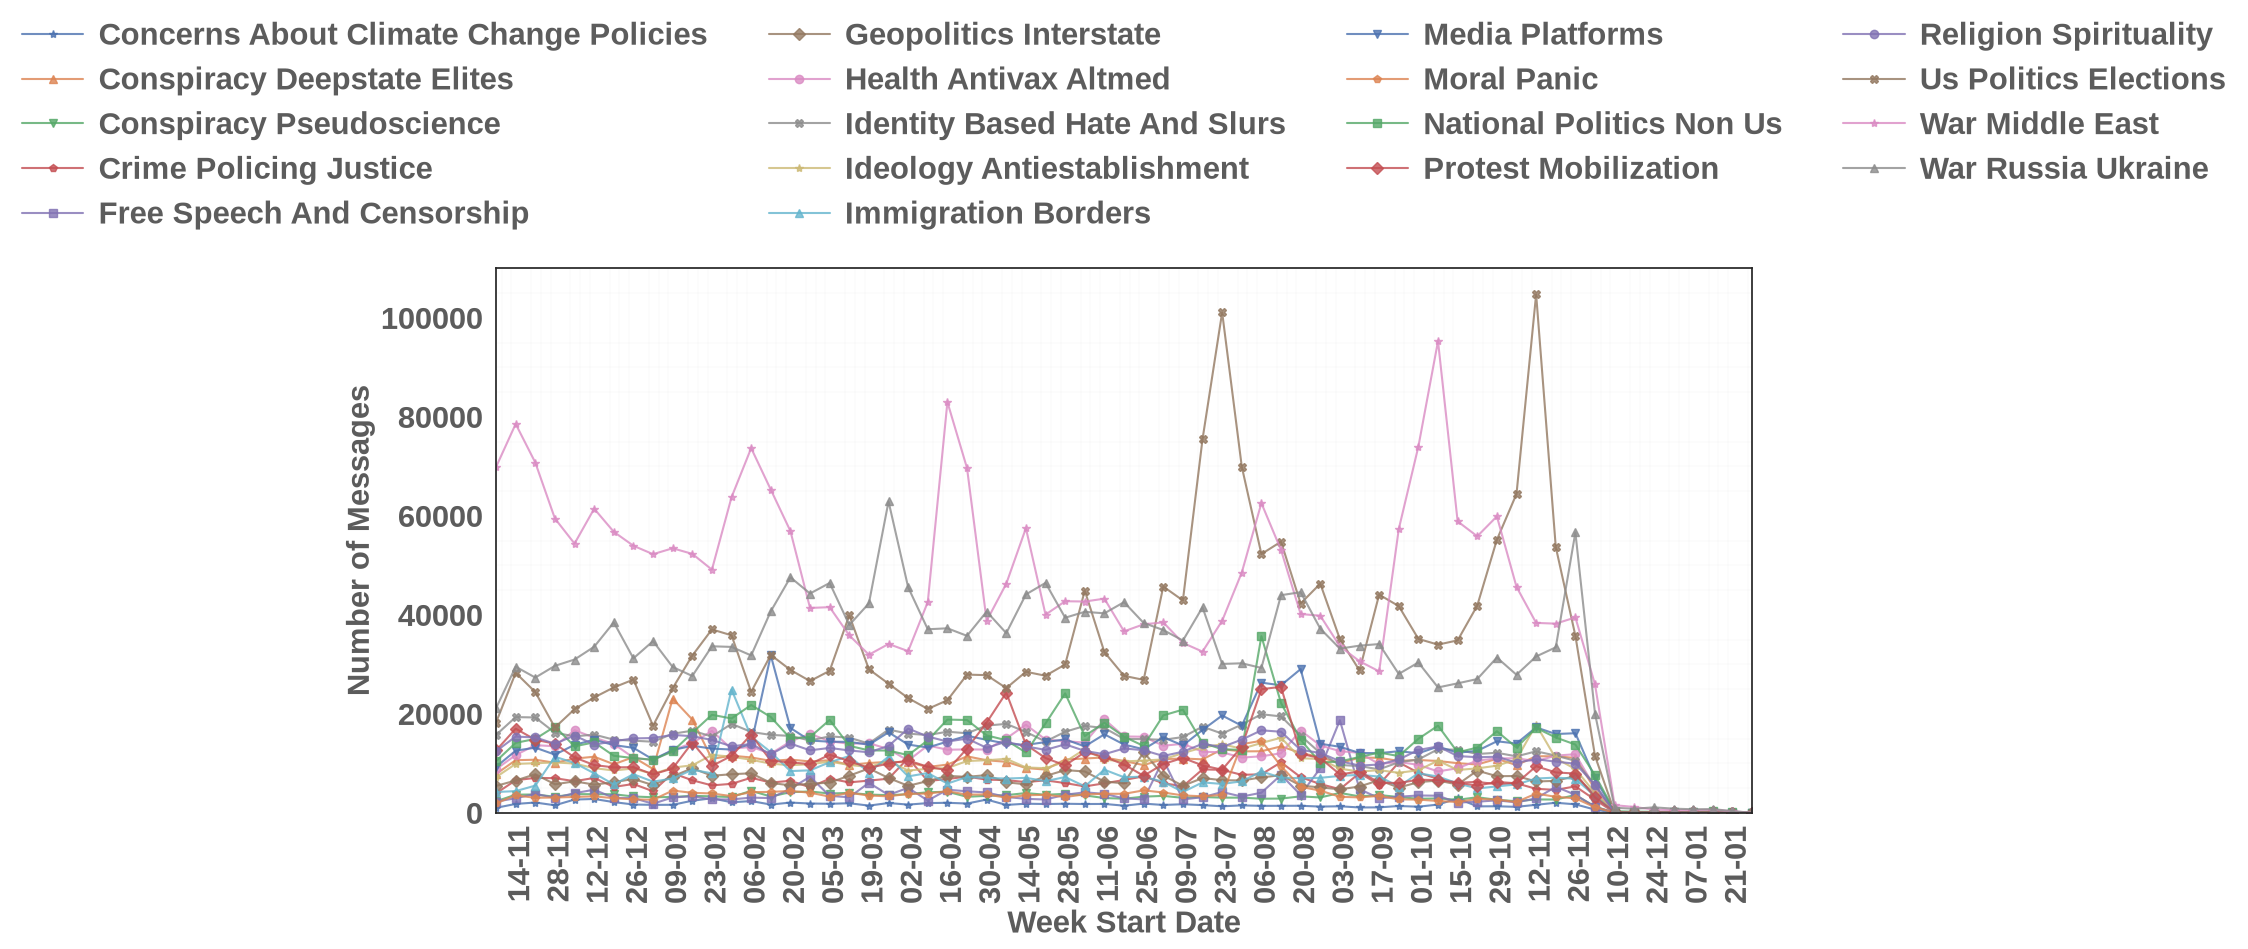

In [15]:
# Conta o número de mensagens por semana (freq='W') para cada tópico
df_weekly = df.groupby([
    pd.Grouper(key='datetime', freq='W'), 
    'macro_topic_norm'
]).size().reset_index(name='count')

# Pivota o dataframe para que cada tópico vire uma coluna (ideal para plotar linhas)
df_pivot = df_weekly.pivot(index='datetime', columns='macro_topic_norm', values='count').fillna(0)

# 4. Configuração da Figura
fig, ax = plt.subplots(figsize=(20, 10))

# Definindo alguns marcadores distintos para replicar o estilo da imagem
markers = ['*', '^', 'v', 'p', 's', 'D', 'o', 'X']

# Loop para plotar cada tópico com uma linha e um marcador diferente
for i, column in enumerate(df_pivot.columns):
    ax.plot(
        df_pivot.index,
        df_pivot[column],
        marker=markers[i % len(markers)],
        linestyle='-', # A maioria das linhas na imagem são tracejadas/pontilhadas
        linewidth=1.5,
        markersize=6,
        alpha=0.8,
        label=column
    )

# 5. Formatação do Eixo X (Apenas Mês/Dia como na imagem)
# A imagem usa o formato Dia-Mês (ex: 01-01, 15-01). 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

# Se quiser estritamente APENAS o mês em texto (ex: Jan, Fev), troque para:
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Define o intervalo dos ticks (ex: a cada 2 semanas para evitar sobreposição)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=90) # Rotaciona os labels em 90 graus

# 6. Estilização do Gráfico
ax.set_xlabel('Week Start Date')
ax.set_ylabel('Number of Messages')

# Adiciona o grid sutil apenas no eixo Y e X
ax = plt.gca()
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)
ax.set_xlim(df_pivot.index.min(), df_pivot.index.max()) # Remove margens laterais vazias
ax.set_ylim(bottom=0) # Garante que o eixo Y comece em 0

# Legenda centralizada no topo e em múltiplas colunas
ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False, # Remove a borda da legenda
    #fontsize=10,
    handletextpad=0.5
)

plt.tight_layout()
plt.show()

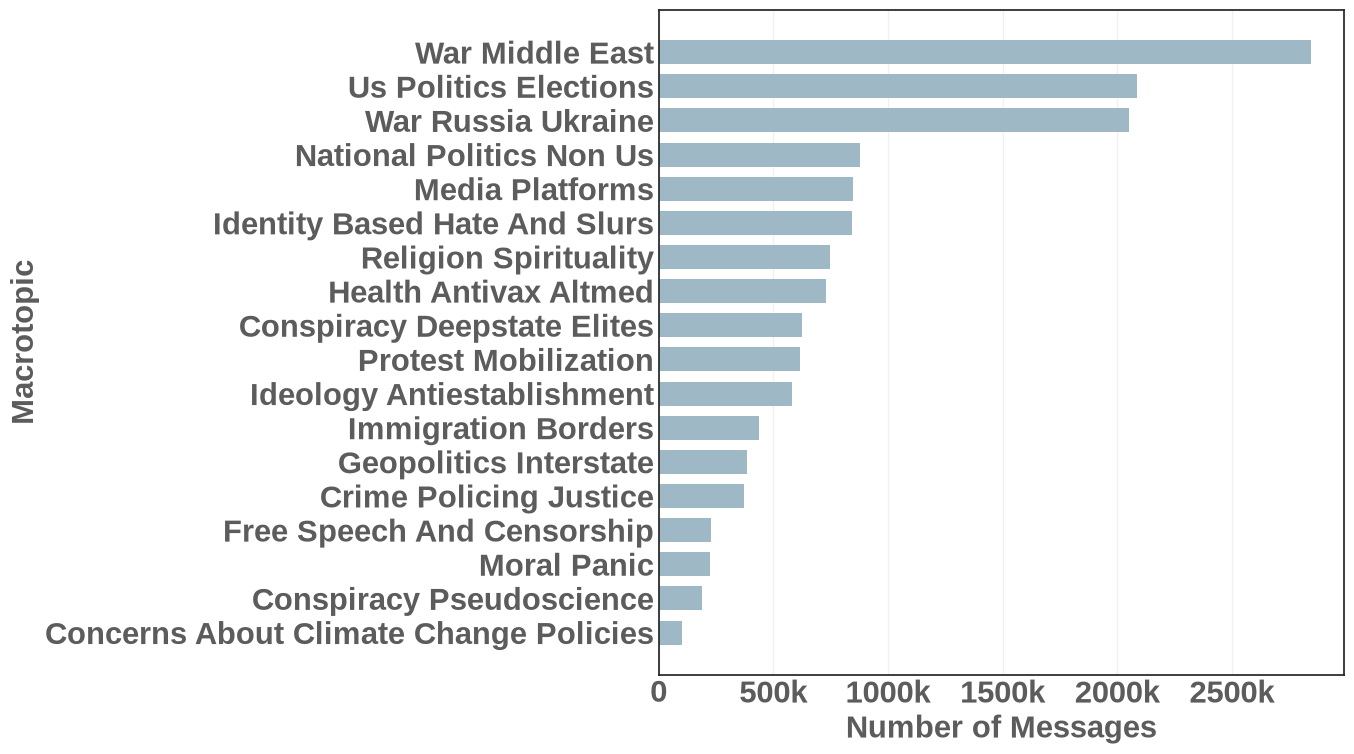

In [20]:
topic_counts = df['macro_topic_norm'].value_counts().sort_values(ascending=True)

# 3. Configurar a figura
fig, ax = plt.subplots(figsize=(14, 8))

cor_pastel = '#9FB8C6' 

# Plotar as barras horizontais
bars = ax.barh(
    topic_counts.index, 
    topic_counts.values, 
    color=cor_pastel, 
    height=0.7,      # Espessura das barras
    edgecolor='none' # Sem borda
)

# 4. Formatação do Eixo X (Adicionar o 'k' para milhares)
def formatar_k(x, pos):
    if x == 0:
        return '0'
    return f'{int(x/1000)}k'

ax.xaxis.set_major_formatter(FuncFormatter(formatar_k))

ax.set_xlabel('Number of Messages')
ax.set_ylabel('Macrotopic')

# Configurar as cores e peso da fonte dos ticks (rótulos dos eixos)
ax.tick_params(axis='both', length=0)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight('bold')

# Adicionar grid sutil apenas no eixo X (linhas verticais)
ax.grid(True, axis='x', linestyle='-', alpha=0.3, color='lightgray')
ax.set_axisbelow(True) # Garante que o grid fique atrás das barras

# Ajustar os limites do eixo X para não sobrar espaço antes do zero
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

In [27]:
df_tox['toxicity'].median()

0.008438602089881897